<div style="background:linear-gradient(135deg,#603813 0%,#b29f94 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">📐&nbsp; Benchmark: Convergence vs. Network Width</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">How big does the network need to be? We sweep hidden-layer width and measure the <i>true</i> solution error against an exact reference — mapping the trade-off between capacity, accuracy, and cost.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">type</span><span style="background:#603813;color:#fff;padding:4px 8px;">benchmark</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">capacity sweep</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

We use the **heat equation** $u_t=\alpha\,u_{xx}$ because it has the exact solution
$u(t,x)=\sin(\pi x)\,e^{-\alpha\pi^2 t}$ — so we can compute a real **relative $L_2$ error**, not
just a training loss. A wider network has more capacity but costs more per step; this study finds the
sweet spot.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#sweep" style="color:#1a73e8;text-decoration:none;">2 · The Width Sweep</a></li>
  <li style="margin:3px 0;"><a href="#results" style="color:#1a73e8;text-decoration:none;">3 · Error vs. Capacity</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">4 · Takeaways</a></li>
  </ol>
</div>

<a id="setup"></a>

## 1 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinn").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnkit
print(f"pinn version : {pinn.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinn version : 0.1.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


In [2]:
from pinnkit.models import MLP

ALPHA = 0.1
def exact(t, x):
    return np.sin(np.pi * x) * np.exp(-ALPHA * np.pi**2 * t)

def heat_residual(model, t, x):
    t = t.clone().requires_grad_(True); x = x.clone().requires_grad_(True)
    u = model(torch.cat([t, x], 1))
    g = lambda y, v: torch.autograd.grad(y, v, torch.ones_like(y),
                                         retain_graph=True, create_graph=True)[0]
    return g(u, t) - ALPHA * g(g(u, x), x)

# Reference grid + exact solution
tg = np.linspace(0, 1, 80, dtype=np.float32); xg = np.linspace(0, 1, 160, dtype=np.float32)
TT, XX = np.meshgrid(tg, xg, indexing="ij"); U_exact = exact(TT, XX)
grid = torch.tensor(np.stack([TT.ravel(), XX.ravel()], 1), dtype=torch.float32, device=DEVICE)

<a id="sweep"></a>

## 2 · The Width Sweep

Every run uses identical data, steps, and seed — only the width changes.

In [3]:
import time
WIDTHS = [4, 8, 16, 32, 64]
records = []
for w in WIDTHS:
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = MLP(2, 4, w, 1).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    losses = []
    t0 = time.time()
    for _ in range(1500):
        t = torch.rand(800, 1, device=DEVICE); x = torch.rand(800, 1, device=DEVICE)
        lp = (heat_residual(model, t, x) ** 2).mean()
        x0 = torch.rand(200, 1, device=DEVICE)
        ic = ((model(torch.cat([torch.zeros_like(x0), x0], 1)) - torch.sin(np.pi*x0)) ** 2).mean()
        tb = torch.rand(200, 1, device=DEVICE)
        bc = (model(torch.cat([tb, torch.zeros_like(tb)], 1)) ** 2).mean() \
           + (model(torch.cat([tb, torch.ones_like(tb)], 1)) ** 2).mean()
        loss = lp + 10*ic + 10*bc
        opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
    with torch.no_grad():
        U = model(grid).cpu().numpy().reshape(TT.shape)
    rel = np.linalg.norm(U - U_exact) / np.linalg.norm(U_exact)
    n_params = sum(p.numel() for p in model.parameters())
    records.append({"width": w, "params": n_params, "rel_l2": rel,
                    "time": time.time() - t0, "losses": losses})
    print(f"width {w:3d} | params {n_params:5d} | relative L2 {rel:.3e} | {records[-1]['time']:.0f}s")

width   4 | params    77 | relative L2 1.537e-02 | 8s


width   8 | params   249 | relative L2 1.499e-02 | 10s


width  16 | params   881 | relative L2 1.033e-02 | 13s


width  32 | params  3297 | relative L2 8.400e-03 | 32s


width  64 | params 12737 | relative L2 8.558e-03 | 32s


<a id="results"></a>

## 3 · Error vs. Capacity

2026-06-27 12:10:05,045 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-27 12:10:05,047 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


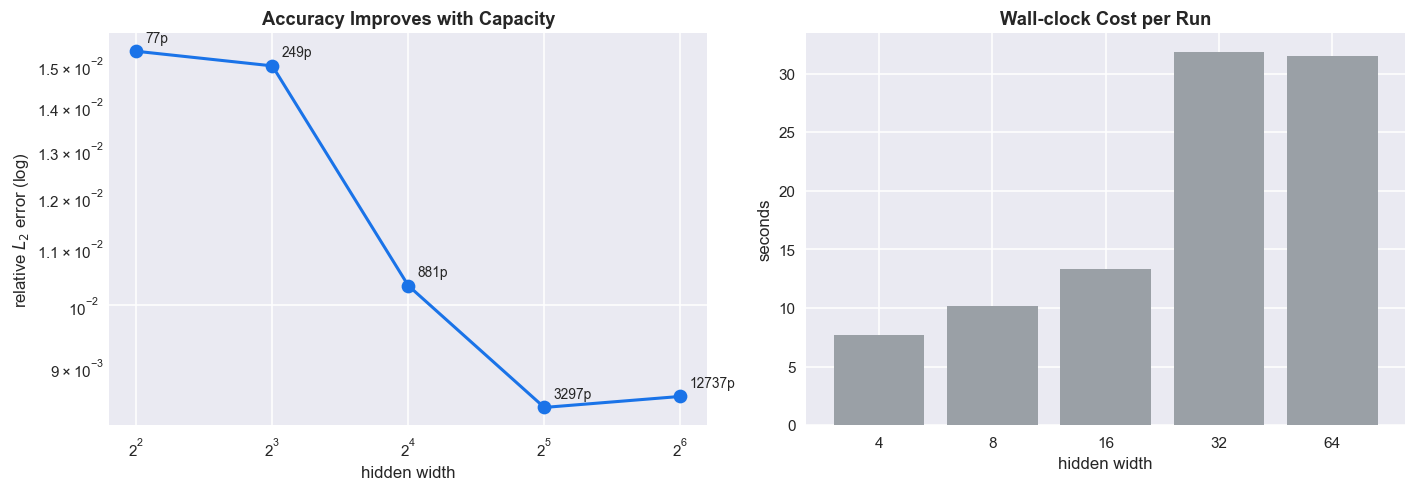

Lowest error: width 32 at 8.40e-03 relative L2.


In [4]:
widths = [r["width"] for r in records]
errs   = [r["rel_l2"] for r in records]
times  = [r["time"] for r in records]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.plot(widths, errs, "o-", color=ACCENT, lw=2, ms=9)
a1.set_xscale("log", base=2); a1.set_yscale("log")
a1.set(title="Accuracy Improves with Capacity", xlabel="hidden width",
       ylabel="relative $L_2$ error (log)")
for r in records:
    a1.annotate(f"{r['params']}p", (r["width"], r["rel_l2"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)

a2.bar([str(w) for w in widths], times, color="#9aa0a6")
a2.set(title="Wall-clock Cost per Run", xlabel="hidden width", ylabel="seconds")
plt.tight_layout(); plt.show()

best = min(records, key=lambda r: r["rel_l2"])
print(f"Lowest error: width {best['width']} at {best['rel_l2']:.2e} relative L2.")

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> Error falls steeply with width and then <b>plateaus</b> — past the knee of the curve you pay more compute for little accuracy. That knee is your sweet spot.
</div>

<a id="takeaways"></a>

## 4 · Takeaways

- Measuring against an **exact solution** turns a vague training loss into a trustworthy error.
- Accuracy improves with width up to a **diminishing-returns plateau**; beyond it you mostly buy
  compute.
- Width is only one axis — collocation count, depth, and loss weighting matter too (see
  [`03_method_comparison`](03_method_comparison.ipynb) and
  [`05_performance_benchmark`](05_performance_benchmark.ipynb)).

### 📚 References

1. Raissi, M. et al. (2019). *Physics-informed neural networks*. J. Comput. Phys., 378.
2. De Ryck, T., & Mishra, S. (2022). *Error analysis for PINNs approximating PDEs*. Advances in Computational Mathematics, 48.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinn</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>